In [1]:
import os
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count=10 --xla_cpu_enable_fast_math=true'

import jax
print(jax.devices())

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import jax.numpy as jnp
import jax 
from jax import grad, vmap
jax.config.update("jax_enable_x64", True)




import scipy.interpolate as interp
import scipy.integrate as integ
import scipy.linalg as sla

import fisher_jim_tgr_v3 as lib
import pycbc.conversions

import astropy.units as u
from astropy import constants as const

Ms = (u.Msun * const.G / const.c**3 ).si.value
from datetime import datetime
datestr = datetime.now().strftime('%m-%d-%y')

import sys
import matplotlib as mpl

# Clear matplotlib from sys.modules
for module in list(sys.modules.keys()):
    if module.startswith("matplotlib"):
        del sys.modules[module]

import matplotlib.pyplot as plt
plt.style.use("paper.mplstyle")
%config InlineBackend.figure_format = 'retina'
obj = lib.Fisher(fmin = 20, fmax = 2000, n_freq = 4000.)

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9)]


/opt/anaconda3/envs/geotgr/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/anaconda3/envs/geotgr/lib/python3.12/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
names = ['M_c', 'eta', 'd_L', 'ra', 'dec', 'iota', 'psi', 't_c', 'phase_c']
data = [0,  0,  0, 1.85631014e+00, -7.31174691e-02,  1.05346794e+00, 9.79787100e-01,  0.00000000e+00,  0.00000000e+00]
# picked random angles here

idx = '150914'
if idx=='150914':
    data_150914 = np.array(data)
    data_150914[0] = 30
    q  = 0.79
    data_150914[1] = q/(1+q)**2
    data_150914[2] = 390
    dat = jnp.array(data_150914)
elif idx=='170817':
    data_150914 = np.array(data)
    data_150914[0] = 3
    q  = 0.79
    data_150914[1] = q/(1+q)**2
    data_150914[2] = 390/10
    dat = jnp.array(data_150914)

red_param = dict(zip(names, jnp.array(dat).T))


epsilon = jnp.array(1e-6)
for key in ['s1_x', 's1_y', 's1_z', 's2_x', 's2_y', 's2_z']:
    red_param[key] = epsilon
zero_vector = jnp.array(0.)
for key in ['gmst', 'epoch']:
    red_param[key] = zero_vector

x = red_param.copy()
x['s1_z'] = 0.
x['s1_x'] = 0.

prec_pe = True
if prec_pe:
    i = None
else:
    i = -2
hgr = obj.get_h_gr(x)
dhgr = obj.get_dh_gr(x)
paramgr = obj.paramdiffgr.copy()[:i]
paramgr_latex = obj.paramdiffgr_latex.copy()[:i]
freqs = obj.freqs.copy()

In [3]:
def get_stuff(kinj):
    norm = lib.get_dpsi_ppe(20, x, kinj)- lib.get_dpsi_ppe(6000, x, kinj)
    dphik = 1/norm
    dpsi_inj = dphik*lib.get_dpsi_ppe(obj.freqs, x, kinj)
    
    Dh = {}
    
    for d in ["H1", "L1", "V1"]:
        Dh[d] = 1j * dpsi_inj * hgr[d] 
    normarr = [lib.innprod(Dh[d], Dh[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]]
    norm = np.sum(normarr)**(1/2) / 5
    dpsi_inj = dpsi_inj/norm
    for d in ["H1", "L1", "V1"]:
        Dh[d] = Dh[d]/norm

    # normarr = [lib.innprod(Dh[d], Dh[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]]
    # print(norm)


    fi = obj.compute_joint_fish(x, paramgr, k = None)
    bias_ip = obj.compute_biasip(x, Dh, paramgr, k = None)
    
    idx_par = obj.idx_par.copy()
    log_flag = obj.log_flag.copy()
    
    cov = jnp.linalg.inv(fi)
    dx_bias = np.array(cov @ bias_ip)
    dx_stat = np.diagonal(np.array(cov ))**(1/2)
    xvals = np.array([x[k] for k in paramgr])

    for p in paramgr:
        if log_flag[p]:
            i = idx_par[p]
            dx_bias[i] = dx_bias[i]*x[p]
            dx_stat[i] = dx_stat[i]*x[p]
    # dhpara = np.zeros_like(freqs)
    dhpara = {}
    dhperp = {}
    for d in ["H1", "L1", "V1"]:
        dhpara[d] = jnp.zeros_like(freqs)
        for p in paramgr:
            dhpara[d] = dhpara[d] +  dx_bias[idx_par[p]]*dhgr[d][p]
            # print(lib.innprod( dx_bias[i]*dhgr[d][p], dhpara[d], obj.psdO3, obj.freqs)**(1/2))
        dhperp[d] = Dh[d] - dhpara[d]
    
    dpsi_perp = np.array((dhperp["H1"])/1j/hgr["H1"])

    snr = np.real(np.sum([lib.innprod(hgr[d], hgr[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]])**(1/2))
    snr_dh = np.real(np.sum([lib.innprod(Dh[d], Dh[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]])**(1/2))
    snr_dhperp = np.real(np.sum([lib.innprod(dhperp[d], dhperp[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]])**(1/2))
    snr_dhpara = np.real(np.sum([lib.innprod(dhpara[d], dhpara[d], obj.psdO3, obj.freqs) for d in ["H1", "L1", "V1"]])**(1/2))
    res = {'freqs' : freqs, 'dpsi_inj' : dpsi_inj, 'dpsi_perp' : dpsi_perp, 'dh' : Dh["H1"], 'h' : hgr["H1"], 'dh_perp' : dhperp["H1"], 'dx_bias' : dx_bias, 'dx_stat' : dx_stat, 'snr':snr, 'snr_dh':snr_dh, 'snr_dhperp':snr_dhperp, 'snr_dhpara':snr_dhpara}



    return res

res = get_stuff(3)

In [ ]:
res = get_stuff(3)



(-0.1, 0.3)

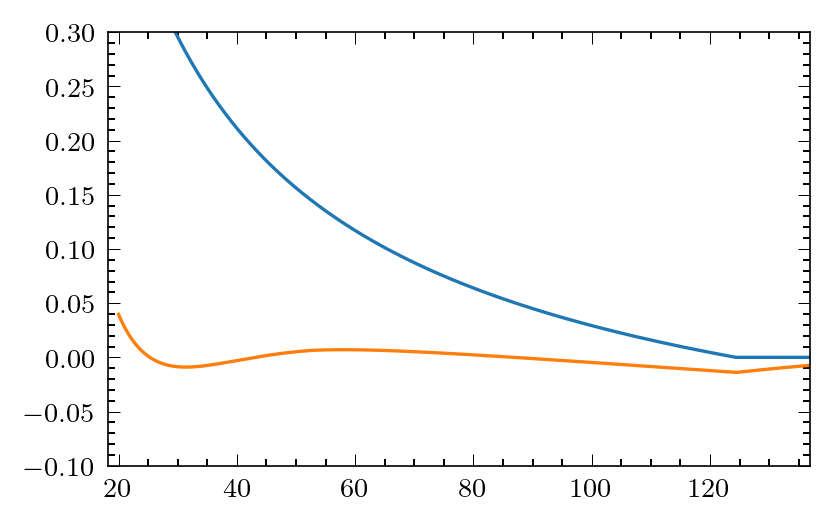

In [17]:

fig, main_ax = plt.subplots(1, 1, figsize=(default_figsize[0]  , default_figsize[1]))

plt.plot(res["freqs"],res["dpsi_inj"].real)
plt.plot(res["freqs"],res["dpsi_perp"].real)
main_ax.set_xlim(obj.fmin/1.1, obj.fend * 1.1)
main_ax.set_ylim(-0.1, 0.3)
# plt.plot(res["freqs"],res["dpsi_perp"].imag)

### Figure 3 generation

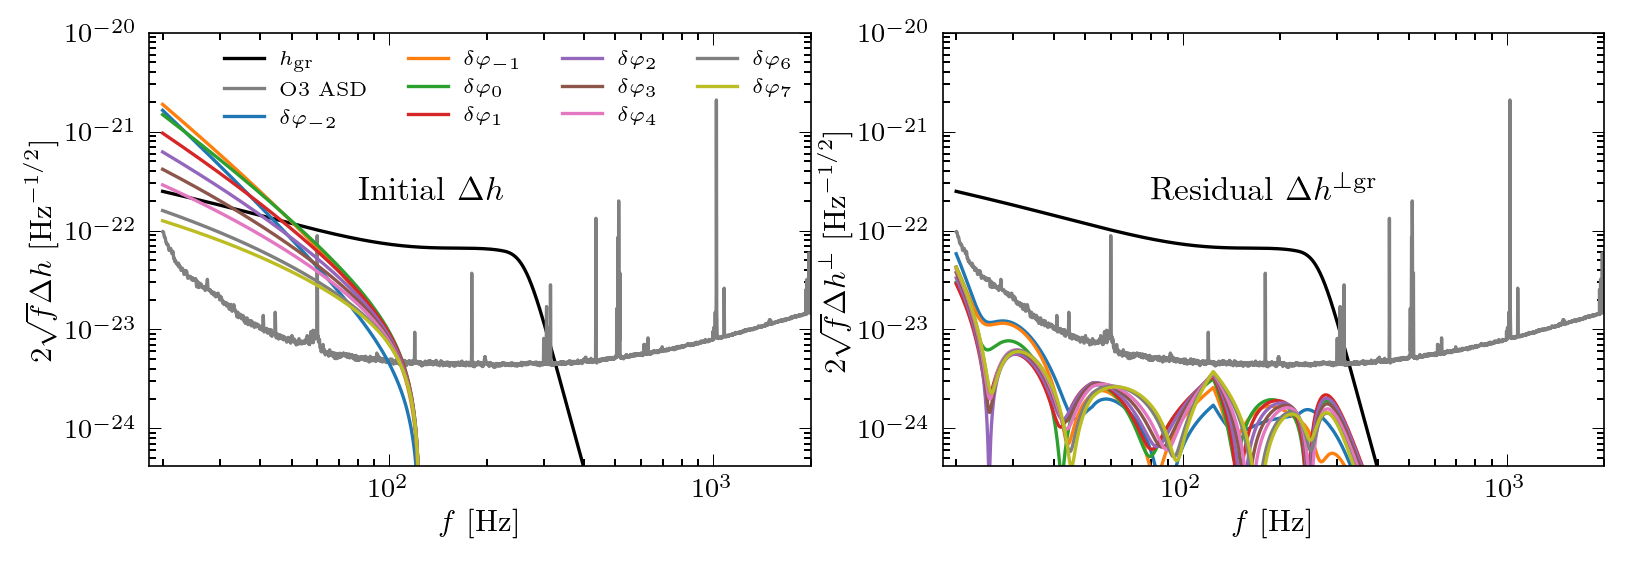

In [4]:
import pandas as pd

res = get_stuff(3)
freqs = res['freqs']
h = res['h']
asd = obj.psdO3**(1/2)
# plt.loglog(freqs, 2*np.sqrt(freqs)*np.abs(h))

default_figsize = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(1, 2, figsize=(default_figsize[0] * 510/246, default_figsize[1]))

line, = axes[0].loglog(freqs, 2*np.sqrt(freqs)*np.abs(h), label=r"$h_\mathrm{gr}$", c = "k")
axes[1].loglog(freqs, 2*np.sqrt(freqs)*np.abs(h), c=line.get_color())

line, = axes[0].plot(freqs, asd, label=r"O3 ASD", c = "grey")
axes[1].plot(freqs, asd, c=line.get_color())

for kinj in [-2, -1, 0, 1, 2, 3, 4, 6, 7]:
    res = get_stuff(kinj)
    norm = res['snr_dhperp'] 
    freqs = res['freqs']
    dh = res['dh']/norm
    dh_perp = res['dh_perp']/norm

    # print()
    
    
    # line, = axes[0].plot(freqs, dpsi_inj - dpsi_inj[i], label=rf"$\delta\varphi_{{ {kinj} }}$")
    # axes[1].plot(freqs, np.real(dpsi_perp - dpsi_perp[i]), c=line.get_color())
    line, = axes[0].plot(freqs, 2*np.sqrt(freqs)*np.abs(dh), label=rf"$\delta \varphi _{{ {kinj} }}$")
    axes[1].plot(freqs, 2*np.sqrt(freqs)*np.abs(dh_perp), c=line.get_color())




axes[0].set_xlim(obj.fmin/1.1, 2000)
axes[0].set_ylim(np.min(asd)/1e1, 1e-20)
axes[0].set_xlabel(r"$f$ [Hz]")
axes[0].set_ylabel(r"$2\sqrt{f}  \Delta h$  [Hz$^{-1/2}$]")
axes[0].legend(loc=1,ncol=4)

axes[1].set_xlim(obj.fmin/1.1, 2000)
axes[1].set_ylim(np.min(asd)/1e1, 1e-20)
axes[1].set_xlabel(r"$f$ [Hz]")
axes[1].set_ylabel(r"$2\sqrt{f} \Delta h^\perp$  [Hz$^{-1/2}$]")

xx, yy = 80, 2e-22
axes[0].annotate(
   r'Initial $\Delta h$', xy=(xx,yy), xycoords='data',
   xytext=(0, 0), textcoords='offset points')
axes[1].annotate(
   r'Residual $\Delta h^{\perp \mathrm{gr}}$', xy=(xx,yy), xycoords='data',
   xytext=(0, 0), textcoords='offset points')
# fig.suptitle("$M_c = 3$")
# plt.savefig("fig3-amplitude-ppe-150914.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

# snr_latex = [r"$\rho_{gr}$",r"$\rho_{dh}$",r"$\rho_{dh_\perp}$",r"$\rho_{dh_\parallel}$"]
# print([res['snr'], res['snr_dh'], res['snr_dhperp'], res['snr_dhpara']])
# pd.DataFrame([res['snr'], res['snr_dh'], res['snr_dhperp'], res['snr_dhpara']],snr_latex, [r"$\rho$"]).round(2)

### Figure 4 generation

/var/folders/8k/w_2008p52f36b9xbnhpbpp700000gn/T/ipykernel_92449/3779563836.py:99: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


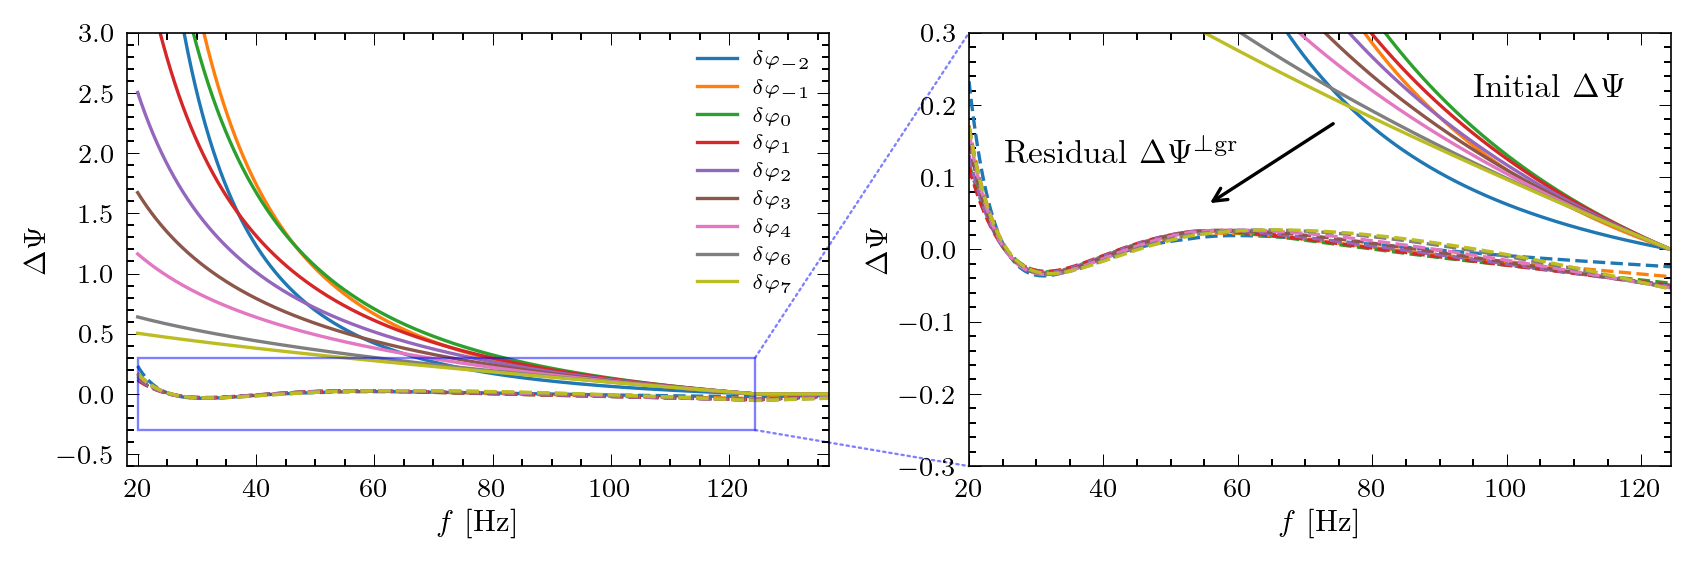

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

from math import isclose; import matplotlib.pyplot as plt
default_figsize = plt.rcParams["figure.figsize"]
fig, main_ax = plt.subplots(1, 1, figsize=(default_figsize[0]  , default_figsize[1]))




snr_dhperp_plt = 1
plt_ratio = 3*snr_dhperp_plt

x1,x2,y1,y2 = obj.fmin/1., obj.fend * 1., -0.1*plt_ratio, 0.1*plt_ratio # subregion of origanal image
inset_ax = main_ax.inset_axes([1.2, 0, 1, 1], xlim=(x1,x2), ylim=(y1,y2))

for kinj in [-2, -1, 0, 1, 2, 3, 4, 6, 7]:
    res = get_stuff(kinj)
    norm = res['snr_dhperp'] / snr_dhperp_plt
    freqs = res['freqs']
    dpsi_inj = res['dpsi_inj']/norm
    dpsi_perp = res['dpsi_perp']/norm
    i = np.argmin((freqs - obj.fend) ** 2)
    
    line, = main_ax.plot(freqs, np.real(dpsi_inj), label=rf"$\delta\varphi_{{ {kinj} }}$")
    main_ax.plot(freqs, np.real(dpsi_perp ), c=line.get_color(), ls = "--")
    # axes[1].plot(freqs, np.real(dpsi_perp ), c=line.get_color())
    inset_ax.plot(freqs, np.real(dpsi_inj), label=rf"$\delta\varphi_{{ {kinj} }}$", c=line.get_color())
    inset_ax.plot(freqs, np.real(dpsi_perp ), c=line.get_color(), ls = "--")

main_ax.set_xlim(obj.fmin/1.1, obj.fend * 1.1)
main_ax.set_ylim(-0.2*plt_ratio, 1*plt_ratio)
main_ax.set_xlabel(r"$f$ [Hz]")
main_ax.set_ylabel(r"$\Delta\Psi$")
main_ax.legend(loc=1)


inset_ax.set_xlabel(r"$f$ [Hz]")
inset_ax.set_ylabel(r"$\Delta\Psi$")



rect = (x1, y1, x2 - x1, y2 - y1)

box = main_ax.indicate_inset(rect, edgecolor="blue", alpha=0.5,lw=0.7)

# Create ConnectionPatches to link main axes and inset axes
cp1 = ConnectionPatch(
    xyA=(x2, y1),             # Lower-left corner in main_ax data coordinates
    xyB=(0, 0),               # Lower-left in inset_ax axes fraction
    axesA=main_ax,
    axesB=inset_ax,
    coordsA="data",
    coordsB="axes fraction",
    edgecolor="blue",
    alpha=0.5,
    lw=0.7,
    ls=":"
)

cp2 = ConnectionPatch(
    xyA=(x2, y2),             # Upper-left corner in main_ax data coordinates
    xyB=(0, 1),               # Upper-left in inset_ax axes fraction
    axesA=main_ax,
    axesB=inset_ax,
    coordsA="data",
    coordsB="axes fraction",
    edgecolor="blue",
    alpha=0.5,
    lw=0.7,
    ls=":"
)

# Add the ConnectionPatches to the main axes
main_ax.add_patch(cp1)
main_ax.add_patch(cp2)

annotate_freq = 60  # Middle frequency
annotate_dpsi_perp = np.real(dpsi_perp[len(freqs) // 2])*plt_ratio

x_end = 55
y_end = (np.real(dpsi_perp[len(freqs) // 2])+0.002)*plt_ratio
x_start = x_end  + 20# No horizontal offset for vertical arrow
y_start = y_end + 0.04*plt_ratio  # Text starts above the annotated point

inset_ax.annotate(
   '', xy=(x_start, y_start), xycoords='data',
   xytext=(x_end, y_end), textcoords='data',
   arrowprops={'arrowstyle': '<-'})
inset_ax.annotate(
   r'Residual $\Delta\Psi^{\perp\mathrm{gr}}$', xy=(x_end/2+x_start/2, y_start/2+y_end/2), xycoords='data',
   xytext=(-80, -0.002*plt_ratio), textcoords='offset points')

inset_ax.annotate(
   r'Initial $\Delta\Psi$', xy=(95,0.07*plt_ratio), xycoords='data',
   xytext=(0, 0), textcoords='offset points')

plt.tight_layout()
# plt.savefig("fig4-dephasing-ppe-illustration-150914.pdf", bbox_inches='tight', pad_inches=0)
plt.show() 